To do:

1. Check dependence of network size on extinction duration
2. Check not only whether the NA converges to the other outcome, but also how fast it does so
3. The structural property that we find to best determine the outcome of the system, may only do so for this paticular rule. How should we generalise this? In case of threshold rules or probabilistic rules, there are certain parameter that you can control. But that's not the case for this specific rule. We could look at other specific rules though, and we could look at different kinds of networks. There are some other rules that split the landscape quite well for small-world networks.
4. A relevant property of small-world networks is the clustering coefficient. This is the method `transitivity_local_undirected` in `igraph` (presumably, check this).
5. Calculate the HW slope and BS of the GLK rule (which is selected to be good at density classification). This rule is given by
$$
\begin{align}
s_i^{t+1} = \begin{cases}
    \text{majority}(s_i^t, s_{i-1}^t, s_{i-3}^t) & \text{if } s_i^t = 0, \\
    \text{majority}(s_i^t, s_{i+1}^t, s_{i+3}^t) & \text{if } s_i^t = 1.
\end{cases}
\end{align}
$$
Note that this is equivalent to
$$
\begin{align}
s_i^{t+1} = \begin{cases}
    s_{i-1}^t \land s_{i-3}^t & \text{if } s_i^t = 0, \\
    s_{i+1}^t \lor s_{i+3}^t & \text{if } s_i^t = 1.
\end{cases}
\end{align}
$$
6. Watts uses genotypical population entropy $\Phi$ instead of rewiring probability. That is probably slightly better, because the same probability can still end up generating a spectrum of 'shortcut' numbers. Watts find best performance for $\Phi$ between 0.6 and 0.8. BUT later in the paper it is shown that constraining the value of $\Phi$ actually leads to better results (so I guess it's an effect of the genetic algorithm).
7. What is the actual performance of the rule that we found? That is not the point, but it is an interesting question to ask. I could check this for all $49$ rules that made the cut. Note that it's only a fair comparison if I have adjust the resolution to the radius in the original problem.

In [2]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble, mean_field_dens_propagation, derrida_map_analytical, hamming_weight, boolean_sens, mean_field_slope

%load_ext autoreload
%autoreload 2

This rule is equivalent to itself.


(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{488,464}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

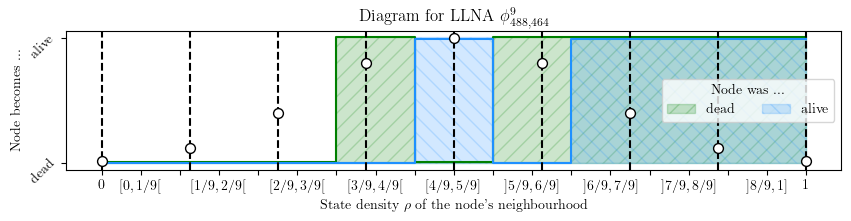

In [4]:
resolution = 9
beta, sigma = (488, 464)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# this rule is equivalent to itself
beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
if (beta, sigma) == (beta_equiv, sigma_equiv):
    print("This rule is equivalent to itself.")

model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram(degree=8, plot_dist=True)

Text(0.5, 0.98, 'Rule $\\phi^9_{488,464}$, degrees $1$ to $20$')

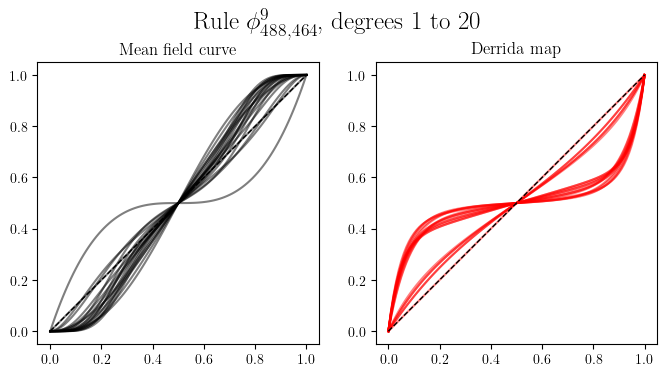

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
fontsize=18

rho0_array = np.linspace(0,1,101)
delta0_array = np.linspace(0,1,101)
degrees= np.arange(1,21,1, dtype=int)

rho1_arrays = np.array([mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree) for degree in degrees])
delta1_arrays = np.array([derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree) for degree in degrees])

for degree, rho1_array, degree1_array in zip(degrees, rho1_arrays, delta1_arrays):
    axs[0].set_title("Mean field curve")
    axs[0].plot(rho0_array, rho1_array, label=f"Degree {degree}", color='k', alpha=0.5)
    axs[1].set_title("Derrida map")
    axs[1].plot(delta0_array, degree1_array, label=f"Degree {degree}", color='r', alpha=0.5)
for ax in axs:
    ax.plot([0,1], [0,1], lw=1, ls='--', color='k')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect(1)

plt.suptitle(f"Rule $\\phi^{resolution}_{{{beta},{sigma}}}$, degrees ${degrees[0]}$ to ${degrees[-1]}$", fontsize=fontsize)

In [6]:
# Parameters
width = 50                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
rewiring_prob = 0.2     # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges) # watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

In [ ]:
idx = 1 # 1 : small world
edge = edges[idx]
graph_name = graph_names[idx]

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 100
num_config = 10
init_dens = 0.5

init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)

# put back in L x L shape 
configs = configs.reshape((num_config, T+1, width, width))

In [58]:
# animations
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib import rcParams
rcParams['animation.embed_limit'] = 256  # Set a higher limit for embedding animations

def make_animation_object(grids, title=None):
    # Set up figure
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grids[0])
    # Update function for animation
    def update(frame):
        im.set_array(grids[frame])
        ax.set_title(title, fontsize=20)
        ax.set_xticks([]); ax.set_yticks([])
        return [im]
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=T+1, interval=100)
    plt.close()
    return ani

In [9]:
# show an animation. small world blijft krioelen voor day&night! random ook.
# threshold model wordt heel saai voor small world en voor random network, dus er is wel degelijk iets te zeggen voor het annealed model

example_idx = 2
ani = make_animation_object(configs[example_idx], title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

Text(0.5, 1.0, 'Rule $\\phi^{9}_{488,464}$ on small-world network with $N=2500$ nodes.')

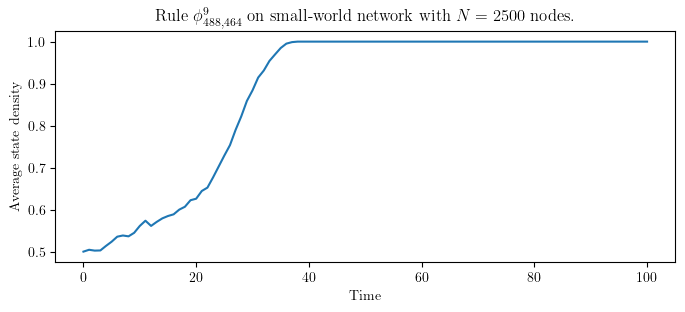

In [10]:
fig, ax = plt.subplots(1,1,figsize=(8,3))
ax.plot(np.mean(configs[example_idx], axis=(1,2)))
ax.set_ylabel(f"Average state density")
ax.set_xlabel(f"Time")
ax.set_title(f"Rule {model.__str__(latex=True)} on small-world network with $N={num_nodes}$ nodes.")

In [ ]:
# save some GIFs for future reference

SAVEGIFS = False
life_like_name = '488-464'

if SAVEGIFS:
    for i, config in tqdm(enumerate(configs), total=configs.shape[0]):
        savename = f"animation_llna_smallworld_{life_like_name}_{width}x{width}_T{T}_sample{i}.gif"

        # example_idx = np.random.randint(num_config)
        ani = make_animation_object(config, title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
        # ani = make_animation_object(defects[example_idx])

        # Save animations as GIFs
        loc = '../figures/gifs/'
        ani.save(loc+savename, writer='pillow', fps=24)  # Using Pillow

        # show inline
        # HTML(ani.to_jshtml())

100%|██████████| 10/10 [01:13<00:00,  7.31s/it]


# Introducing defects for tipping the scales

### First for a single initial configuration

In [12]:
# check the final density of the configurations. We're looking for one that goes extinct.
idx = 0
config = configs[idx]
print(f"The final state density is {np.mean(config[-1])}.")

The final state density is 0.0.


In [13]:
# flatten initial configuration
init_config = config[0].reshape(width**2)

# obtain degrees
degrees = np.array(graphs[1].degree())
sorted_indices = np.argsort(degrees)

# find and report max degrees
max_degree = np.max(degrees)
max_degree_indices = np.where(degrees == max_degree)[0]
max_degree_alive = np.sum(init_config[max_degree_indices])
almost_max_degree_indices = np.where(degrees == max_degree-1)[0]
almost_max_degree_alive = np.sum(init_config[almost_max_degree_indices])
print(f"There are {np.sum(degrees == max_degree)} nodes with the maximum degree {max_degree}. {max_degree_alive} are alive.")
print(f"There are {np.sum(degrees == max_degree-1)} nodes with the degree {max_degree-1}. {almost_max_degree_alive} are alive.")
print(f"")

min_degree = np.min(degrees)
min_degree_indices = np.where(degrees == min_degree)[0]
min_degree_alive = np.sum(init_config[min_degree_indices])
almost_min_degree_indices = np.where(degrees == min_degree+1)[0]
almost_min_degree_alive = np.sum(init_config[almost_min_degree_indices])
print(f"There are {np.sum(degrees == min_degree)} nodes with the minimum degree {min_degree}. {min_degree_alive} are alive.")
print(f"There are {np.sum(degrees == min_degree+1)} nodes with the degree {min_degree+1}. {almost_min_degree_alive} are alive.")

There are 12 nodes with the maximum degree 12. 9 are alive.
There are 41 nodes with the degree 11. 22 are alive.

There are 3 nodes with the minimum degree 4. 1 are alive.
There are 27 nodes with the degree 5. 16 are alive.


In [90]:
def switch_life_to_higher_node_property_values(node_property_values, init_config, number_of_switches, kill_low_values=True):
    if number_of_switches<0:
        raise ValueError(f"The number of switches must be a nutural number. Not {number_of_switches}.")
    # get all values of this metric
    num_nodes = len(init_config)
    if len(node_property_values) != num_nodes:
        raise ValueError(f"The number of nodes and the number of initial states do not match.")
    if number_of_switches > num_nodes//2:
        raise ValueError(f"You cannot switch places of more than half of the nodes.")
    default_value = 0
    if not kill_low_values:
        default_value = 1

    # get the indices of all nodes sorted by the node property
    sorted_node_indices = np.argsort(node_property_values)
    sorted_values = node_property_values[sorted_node_indices]
    # find unique values
    unique_values = np.unique(node_property_values)
    # if there not all values are unique, randomize the order within each subgroup with the same node property value
    if len(unique_values) != num_nodes:
        # Randomize within groups (to avoid other correlations)
        shuffled_sorted_node_indices = np.empty_like(sorted_node_indices)
        start = 0
        for unique_value in unique_values:
            # find where the indices correspond to the current node property value
            val_indices = np.where(sorted_values == unique_value)[0]
            # get the subarray of values coresponding to this value
            group = sorted_node_indices[val_indices]
            # randomise the group
            np.random.shuffle(group)
            # glue the pieces back together
            shuffled_sorted_node_indices[start:start + len(group)] = group
            start += len(group)
        # order the initial configuration according to the shuffled value-sorted indices
        init_config_shuffle_ordered = init_config[shuffled_sorted_node_indices]
    else:
        shuffled_sorted_node_indices = sorted_node_indices
        init_config_shuffle_ordered = init_config[shuffled_sorted_node_indices]
        
    # find the shuffled indices with low node property whose node is alive and kill 'em dead (by default)
    indices_where_alive = np.where(init_config_shuffle_ordered==1-default_value)[0][:number_of_switches]
    init_config_shuffle_ordered[indices_where_alive] = default_value-0
    # same for shuffled indices with high node property of dead nodes that are brought to life (by default)
    indices_where_dead  = np.where(init_config_shuffle_ordered==default_value-0)[0]
    number_of_dead = len(indices_where_dead)
    indices_where_dead = indices_where_dead[(number_of_dead-number_of_switches):]
    init_config_shuffle_ordered[indices_where_dead] = 1-default_value
    # undo the ordering
    init_config_switched = init_config_shuffle_ordered[np.argsort(shuffled_sorted_node_indices)]
    return init_config_switched

def node_h_index(graph):
    h_indices = []
    degrees = graph.degree()

    for v in range(graph.vcount()):
        neighbor_degrees = [degrees[n] for n in graph.neighbors(v)]
        neighbor_degrees.sort(reverse=True)

        h = 0
        for i, deg in enumerate(neighbor_degrees, start=1):
            if deg >= i:
                h = i
            else:
                break
        h_indices.append(h)

    return h_indices

def average_neighbor_degrees(g: ig.Graph):
    """
    Compute the average degree of neighbors for each vertex in a graph.
    
    Parameters:
        g (igraph.Graph): The input graph.
        mode (str): For directed graphs - 'IN', 'OUT', or 'ALL'.
        
    Returns:
        np.ndarray: Array of average neighbor degrees for each vertex.
    """
    # Get degrees of all vertices
    deg = np.array(g.degree())

    # Get adjacency list (neighbors) for each vertex
    neighbors = g.neighborhood()

    # Preallocate result array
    avg_deg = np.zeros(g.vcount())

    for i, nbrs in enumerate(neighbors):
        if nbrs:
            avg_deg[i] = deg[nbrs].mean()
        else:
            avg_deg[i] = 0  # Or np.nan if you prefer

    return avg_deg


In [65]:
graph = small_world_graph_array[1]
total=500
node_property_name = "closeness"
node_property_values = np.array(graph.closeness()) # np.random.permutation(num_nodes)
kill_low_values = True


init_config_stack = init_config.copy()
for number_of_switches in tqdm(range(total), total=total):
    init_config_switched = switch_life_to_higher_node_property_values(node_property_values, init_config, number_of_switches, kill_low_values=kill_low_values)
    init_config_stack = np.vstack((init_config_stack, init_config_switched))

NameError: name 'init_config' is not defined

In [16]:
sorted_node_indices = np.argsort(node_property_values)

fig, ax = plt.subplots(1,1,figsize=(25,3))

ax.imshow(init_config_stack[:,sorted_node_indices], cmap='Greys')
ax.set_title(f"Ordered by {node_property_name}", fontsize=20)

print(f"If kill_low_values is True, you should see increasing white on the left")

NameError: name 'node_property_values' is not defined

Text(0, 0.5, 'h-index')

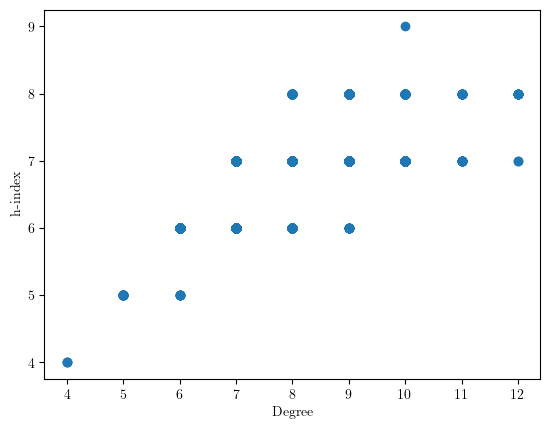

In [172]:
plt.scatter(graph.degree(), node_property_values)
plt.xlabel("Degree")
plt.ylabel(f"{node_property_name}")

Now do run this for many more graphs, many more initial configurations, and many more structural node properties! And make sure to average over the switches (cause the order is chosen randomly as well). Also, make sure to compare to random switching.

### 1. Make many small-world graphs

In [106]:
# Parameters
width = 50                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
num_graphs = 30
rewiring_prob = 0.2         # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph_array = np.array([watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in tqdm(range(num_graphs), total=num_graphs)])

# find edges
small_world_edges_list = []
for small_world_graph in small_world_graph_array:
    small_world_graph.to_directed()
    small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
    small_world_edges_list.append(small_world_edges)
    small_world_graph.to_undirected()
# small_world_edges_array = np.array(small_world_edges_list)

100%|██████████| 30/30 [00:43<00:00,  1.45s/it]


### 2. Make multiple runs on these graphs

In [107]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 100
num_config = 10
init_dens = 0.5

configs_list = []
for small_world_edges in tqdm(small_world_edges_list, total=num_graphs):
    # run the network automaton
    init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
    configs = model.forward(small_world_edges, tc.tensor(init_configs), T=T).numpy().astype(int)
    # put back in L x L shape 
    configs = configs.reshape((num_config, T+1, width, width))
    configs_list.append(configs)
configs_array = np.array(configs_list)

100%|██████████| 30/30 [00:31<00:00,  1.04s/it]


In [108]:
ani = make_animation_object(configs_array[0,7], title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

### 3. Select all combinations (graph, init_config) that result in extinction

Observation: there is a natural spread over the graphs. The capacity of going extinct is not super dependent on the particular adjacency matrix.

In [109]:
extinction_automata_per_graph = []
for idx, small_world_graph in enumerate(small_world_graph_array):
    configs_per_graph = configs_array[idx]
    configs_mask = np.mean(configs_per_graph[:,-1], axis=(1,2))==0
    extinction_automata_per_graph.append(configs_per_graph[configs_mask])

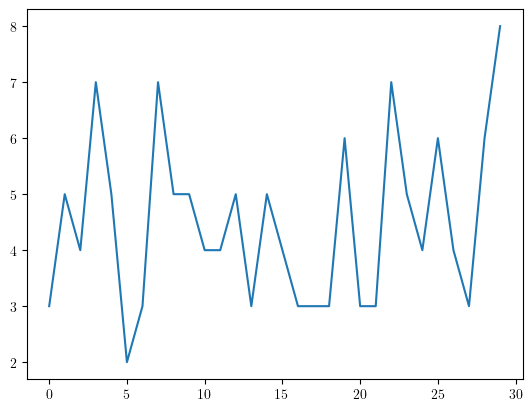

In [110]:
extinctions_per_graph = [extinction_automata_per_graph[idx].shape[0] for idx in range(num_graphs)]
plt.plot(extinctions_per_graph)

### 4. Run over all graphs and intial configurations that lead to extinction, and try to avoid extinction

Observation: a lot of systems will already flip their behaviour even after a single state switch!

(array([ 73., 250., 749., 605., 466., 270.,  62.,  23.,   0.,   2.]),
 array([0.        , 0.06666667, 0.13333333, 0.2       , 0.26666667,
        0.33333333, 0.4       , 0.46666667, 0.53333333, 0.6       ,
        0.66666667]),
 <BarContainer object of 10 artists>)

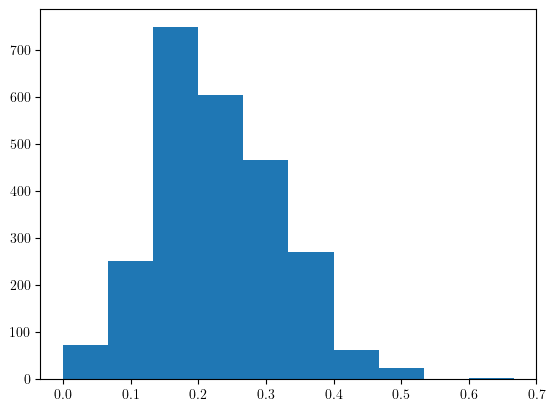

In [112]:
node_property_values = np.array(np.random.choice(small_world_graph_array).transitivity_local_undirected(mode='zero')) # np.random.permutation(num_nodes)
plt.hist(node_property_values)

100%|██████████| 500/500 [00:00<00:00, 605.43it/s] 


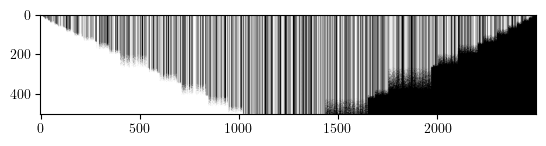

In [113]:
init_config = init_config_with_dens(num_nodes, init_dens)

graph = small_world_graph_array[0]
total=500
node_property_name = "clustering-coefficient"
node_property_values = np.array(graph.transitivity_local_undirected(mode='zero')) # np.random.permutation(num_nodes)
kill_low_values = True

init_config_stack = init_config.copy()
for number_of_switches in tqdm(range(total), total=total):
    init_config_switched = switch_life_to_higher_node_property_values(node_property_values, init_config, number_of_switches, kill_low_values=kill_low_values)
    init_config_stack = np.vstack((init_config_stack, init_config_switched))

init_config_stack_ordered = init_config_stack[:,np.argsort(node_property_values)]
plt.imshow(init_config_stack_ordered, cmap='Greys')

In [114]:
# this creates a list for entries per graph.
# each entry has dimensions (max_switches, extinctions_per_graph, T+1, width, width)

#################################
# NOTE: change the value here!! #
#################################

print(f"Working on node property `{node_property_name}`")

max_switches = 100
configs_switched_list = []
for extinction_automata, small_world_graph, small_world_edges in tqdm(zip(extinction_automata_per_graph, small_world_graph_array, small_world_edges_list), total=num_graphs):
    extinctions_per_graph = extinction_automata.shape[0]
    ###############################################################
    node_property_values = np.array(small_world_graph.transitivity_local_undirected(mode='zero')) # np.random.permutation(num_nodes)
    ###############################################################
    if extinctions_per_graph>0:
        init_configs = extinction_automata[:,0].reshape(extinctions_per_graph, width**2)
        init_configs_switched = []
        # also run over no-switch (makes life a little easier)
        for number_of_switches in range(0,max_switches+1):
            # add them together so we can use the parallellisation of the GNN
            for init_config in init_configs:
                init_config_switched = switch_life_to_higher_node_property_values(node_property_values, init_config, number_of_switches, kill_low_values=kill_low_values)
                init_configs_switched.append(init_config_switched)
        init_configs_switched = np.array(init_configs_switched)
        configs_switched = model.forward(small_world_edges, tc.tensor(init_configs_switched), T=T).numpy().astype(int)
        configs_switched = configs_switched.reshape(max_switches+1, extinctions_per_graph, T+1, width, width)
        configs_switched_list.append(configs_switched)
    else:
        configs_switched_list = configs_switched_list + [None]

Working on node property `clustering-coefficient`


100%|██████████| 30/30 [09:11<00:00, 18.39s/it]


### 5. Show an example of a single switch that can change the entire outcome

In [115]:
graph_idx = 0
first_idx_with_extinction = 0
first_idx_with_full_population = 0
while True:
    config_with_extinction = configs_array[graph_idx,first_idx_with_extinction]
    if np.sum(config_with_extinction[-1])==0:
        config_switched_with_full_population = configs_switched_list[graph_idx][1,first_idx_with_full_population]
        if np.sum(config_switched_with_full_population[-1])==num_nodes:
            break
        first_idx_with_full_population += 1
    first_idx_with_extinction += 1

In [116]:
# original animation

ani = make_animation_object(config_with_extinction, title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [117]:
# animation with tiny change

ani = make_animation_object(config_switched_with_full_population, title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [118]:
# animation of the difference pattern

configs_defect = np.bitwise_xor(config_with_extinction, config_switched_with_full_population)

ani = make_animation_object(configs_defect, title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

By the way, I checked whether this is identical to running the defect as an initial condition. But that's certainly not the case. Clearly that could not be the case, cause the system will kill any seeds.

### 6. Make a scatter plot showing the average influence of switching states

Save _all_ data (quite heavy, not recommended for now)

In [119]:
print(f"Name node property: {node_property_name}")
SAVEDATA = False

if SAVEDATA:
    num_nodes = 2500
    degree = 8
    resolution = 9

    beta, sigma = (488, 464)
    B_set = binary_indices(beta)
    S_set = binary_indices(sigma)
    model = LLNA(resolution, B_set, S_set, iso=True)

    np.save(f"configs_array_{node_property_name}_N{num_nodes}_{model.__str__()}_degree{degree}.npy", configs_array)
    with open(f"configs_switched_list_{node_property_name}_N{num_nodes}_{model.__str__()}_degree{degree}.pickle", 'wb') as handle:
        pickle.dump(configs_switched_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

Name node property: clustering-coefficient


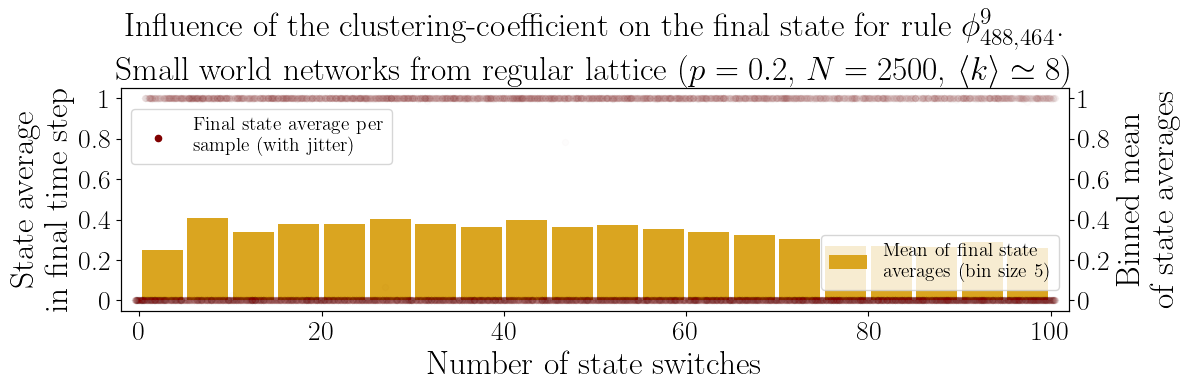

In [121]:
SAVEFIG = True
SAVEDATA = True

fig, ax1 = plt.subplots(1,1,figsize=(12,4))
fontsize=20
# Create the secondary y-axis
ax2 = ax1.twinx()

alpha=0.01

# open list where all y values are kept (which we will average over later)
y_vals_total = []
# loop over the 30 graphs
for i, configs_switched in enumerate(configs_switched_list):
    if configs_switched is not None:
        # loop over the initial conditions that led to extinction
        number_of_extinctions = configs_switched.shape[1]
        for sample_idx in range(number_of_extinctions):
            hjitter = np.random.random(max_switches+1)-0.5
            x_vals = np.arange(max_switches+1)+hjitter
            y_vals = np.mean(configs_switched[:,sample_idx,-1], axis=(1,2))
            y_vals_total.append(y_vals)
            label=None
            if i==0 and sample_idx==0:
                label='Final state average per\nsample (with jitter)'
            ax1.scatter(x_vals, y_vals, color='maroon', alpha=alpha, s=20, label=label, zorder=10)

y_vals_total = np.array(y_vals_total)
if SAVEDATA:
    np.save(f"final_states_after_switching_based_on_{node_property_name}_N{num_nodes}_{model.__str__()}_degree{degree}.npy", y_vals_total)

# Average over all samples
y_vals_avg = np.mean(y_vals_total, axis=0)  # shape: (max_switches + 1,)

# Bin into intervals of 5
bin_width = 5
bins = np.arange(0, max_switches + 2, bin_width)  # +2 to include max_switches
bin_centers = (bins[:-1] + bins[1:]) / 2

binned_means = []
for i in range(len(bins) - 1):
    start, end = bins[i], bins[i+1]
    bin_avg = np.mean(y_vals_avg[start:end])
    binned_means.append(bin_avg)

# Overlay bar chart
ax2.bar(bin_centers, binned_means, width=bin_width*0.9, color='goldenrod', alpha=1, zorder=0, label=f'Mean of final state\naverages (bin size ${bin_width}$)')

# make axis pretty
ax1.set_ylim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax1.set_xlim(-2, 102)
xticks = [0, 20, 40, 60, 80, 100]
yticks = [0, .2, .4, .6, .8, 1]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, fontsize=fontsize)
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
ax1.set_yticklabels(yticks, fontsize=fontsize)
ax2.set_yticklabels(yticks, fontsize=fontsize)
ax1.set_xlabel("Number of state switches", fontsize=fontsize+4)
ax1.set_ylabel(f"State average\nin final time step", fontsize=fontsize+4)
ax2.set_ylabel(f"Binned mean\nof state averages", fontsize=fontsize+4)

legend = ax1.legend(loc='upper left', bbox_to_anchor=(0,.95), fontsize=fontsize-6)
for handle in legend.legend_handles:
    handle.set_alpha(1)
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.05), fontsize=fontsize-6)
# ax2.legend(loc='upper right', bbox_to_anchor=(1,0.95), fontsize=fontsize-6)

# make sure the scatter plot is in front of the bar plot
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)  # This is critical!

# set a title
ax1.set_title(f"Influence of the {node_property_name} on the final state for rule {model.__str__(latex=True)}.\nSmall world networks from regular lattice ($p=0.2$, $N={num_nodes}$, $\\langle k \\rangle \\simeq 8$)", fontsize=fontsize+4)

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f"influence-of-{node_property_name}-on-outcome.pdf")

### 7. Find when it first hits X percent for all structural properties

We use LOWESS for this: locally weighted scatterplot smoothing.

> Cleveland, W.S. (1979) “Robust Locally Weighted Regression and Smoothing Scatterplots”. Journal of the American Statistical Association 74 (368): 829-836.

In [124]:
node_property_name = "clustering-coefficient"
num_nodes = 50**2
degree = 8

resolution = 9
beta, sigma = (488, 464)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)

y_vals_total = np.load(f"../presentation/CompleNet2025/data/final_states_after_switching_based_on_{node_property_name}_N{num_nodes}_{model.__str__()}_degree{degree}.npy")
y_vals_total.shape

(135, 101)

The smoothed curve crosses threshold 0.90 at x ≈ -4000.07


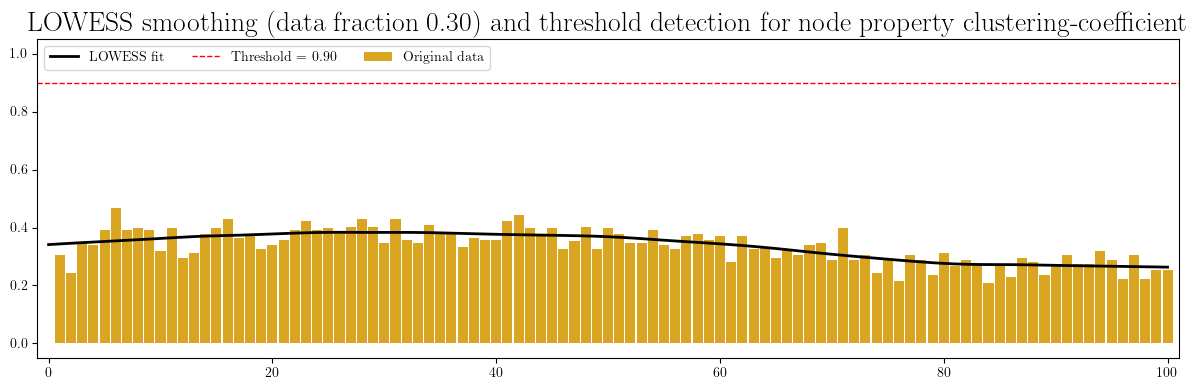

In [127]:
SAVEFIG=False

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d

fig, ax = plt.subplots(1,1,figsize=(12,4))
fontsize=20

# Average over all samples
y_vals_avg = np.mean(y_vals_total, axis=0)  # shape: (max_switches + 1,)

# Bin into intervals of 5
bin_width = 1
max_switches = y_vals_avg.shape[0] - 1
bins = np.arange(0, max_switches + 2, bin_width)  # +2 to include max_switches
bin_centers = (bins[:-1] + bins[1:]) / 2 - 0.5

binned_means = []
for i in range(len(bins) - 1):
    start, end = bins[i], bins[i+1]
    bin_avg = np.mean(y_vals_avg[start:end])
    binned_means.append(bin_avg)

# Apply LOWESS smoothing
frac=0.3
smoothed = lowess(binned_means, bin_centers, frac=frac)  # frac controls smoothness (0.1 = less smooth, 0.3 = more smooth)
x_smooth = smoothed[:, 0]
y_smooth = smoothed[:, 1]

threshold = .9

# Plot original and smoothed
ax.bar(bin_centers, binned_means, color='goldenrod', label='Original data', width=.9)
ax.plot(x_smooth, y_smooth, color='black', linewidth=2, label='LOWESS fit')
ax.set_ylim([-0.05, 1.05])
ax.set_xlim([bin_centers[0]-1, bin_centers[-1]+1])
ax.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.2f}', lw=1)
ax.legend(ncol=3, loc='upper left')
ax.set_title(f'LOWESS smoothing (data fraction {frac:.2f}) and threshold detection for node property {node_property_name}', fontsize=fontsize)

fig.tight_layout()

# Interpolate to find when smoothed curve hits threshold
interp = interp1d(y_smooth, x_smooth, bounds_error=False, fill_value="extrapolate")
x_at_threshold = interp(threshold)

print(f"The smoothed curve crosses threshold {threshold:.2f} at x ≈ {x_at_threshold:.2f}")


So far we found the following order for the questions: after how many switches do 90 percent of the altered configurations lead to full population?
- Eigenvector centrality: 61.07
- Degree: 67.17
- h-index: 76.58
- PageRank: 78.85
- Betweenness: 81.77
- Closeness: 106.77
- Average neighbour degree: 125.43
- Clustering coefficient: [_negative correlation_]